In [1]:
%pip install torch torchvision opacus -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from opacus import PrivacyEngine
from torch import nn, optim
import torch
from torchvision import datasets, transforms

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('.', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=64,
    shuffle=True
)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = optim.SGD(model.parameters(), lr=0.1)

privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.1,
    max_grad_norm=1.0,
)

criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader:
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

print("DP training complete")
epsilon = privacy_engine.get_epsilon(delta=1e-5)
print("ε =", epsilon)


c:\Users\Adi\AppData\Local\Programs\Python\Python311\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\Adi\AppData\Local\Temp\ipykernel_30656\3092667797.py:38: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


DP training complete
ε = 0.23207688268473753


In [3]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from opacus import PrivacyEngine
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIGURATION
# -----------------------------
EPSILONS = [1, 3, 15, 25]   # DP-SGD runs
EPOCHS = 5
BATCH_SIZE = 128
LR = 0.1
MAX_GRAD_NORM = 1.0

# Storage for graphs
results = {
    "non_dp": {"acc": [], "loss": []},
    "dp": {}
}

# Transform
transform = transforms.Compose([transforms.ToTensor()])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(".", train=False, download=True, transform=transform),
    batch_size=1024,
    shuffle=False
)


# -----------------------------
# Helper: Evaluate accuracy
# -----------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0
    loss_fn = nn.CrossEntropyLoss()
    test_loss = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(-1, 28*28)
            preds = model(x)
            test_loss += loss_fn(preds, y).item()
            correct += (preds.argmax(1) == y).sum().item()
            total += y.size(0)

    return correct / total, test_loss / len(test_loader)


# -----------------------------
# 1️⃣ TRAIN: Non-DP SGD Baseline
# -----------------------------
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

opt = optim.SGD(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

print("\n=== Training NON-DP SGD ===")
for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x = x.view(-1, 28*28)
        opt.zero_grad()
        preds = model(x)
        loss = loss_fn(preds, y)
        loss.backward()
        opt.step()

    acc, test_loss = evaluate(model)
    results["non_dp"]["acc"].append(acc)
    results["non_dp"]["loss"].append(test_loss)
    print(f"Epoch {epoch+1}: acc={acc:.4f} loss={test_loss:.4f}")


# -----------------------------
# 2️⃣ TRAIN: DP-SGD for ε = 1,5,10
# -----------------------------
for epsilon in EPSILONS:
    print(f"\n=== Training DP-SGD (ε={epsilon}) ===")

    # fresh model
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

    opt = optim.SGD(model.parameters(), lr=LR)
    privacy_engine = PrivacyEngine()

    # compute noise multiplier required for target epsilon
    model, opt, dp_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=opt,
        data_loader=train_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        epochs=EPOCHS,
        max_grad_norm=MAX_GRAD_NORM
    )

    loss_fn = nn.CrossEntropyLoss(reduction="mean")
    acc_list, loss_list = [], []

    for epoch in range(EPOCHS):
        model.train()
        for x, y in dp_loader:
            x = x.view(-1, 28*28)
            opt.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)
            loss.backward()
            opt.step()

        acc, test_loss = evaluate(model)
        acc_list.append(acc)
        loss_list.append(test_loss)
        print(f"Epoch {epoch+1}: acc={acc:.4f} loss={test_loss:.4f}")

    results["dp"][epsilon] = {"acc": acc_list, "loss": loss_list}



=== Training NON-DP SGD ===
Epoch 1: acc=0.9109 loss=0.3161
Epoch 2: acc=0.9289 loss=0.2501
Epoch 3: acc=0.9395 loss=0.2125
Epoch 4: acc=0.9470 loss=0.1820
Epoch 5: acc=0.9522 loss=0.1618

=== Training DP-SGD (ε=1) ===


c:\Users\Adi\AppData\Local\Programs\Python\Python311\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\Adi\AppData\Local\Programs\Python\Python311\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
C:\Users\Adi\AppData\Local\Temp\ipykernel_30656\1844375851.py:127: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch 1: acc=0.7984 loss=0.6508
Epoch 2: acc=0.8621 loss=0.4515
Epoch 3: acc=0.8810 loss=0.4092
Epoch 4: acc=0.8895 loss=0.3995
Epoch 5: acc=0.8933 loss=0.3990

=== Training DP-SGD (ε=3) ===
Epoch 1: acc=0.8070 loss=0.6265
Epoch 2: acc=0.8642 loss=0.4436
Epoch 3: acc=0.8781 loss=0.4119
Epoch 4: acc=0.8888 loss=0.3952
Epoch 5: acc=0.8932 loss=0.3903

=== Training DP-SGD (ε=15) ===
Epoch 1: acc=0.7938 loss=0.6452
Epoch 2: acc=0.8582 loss=0.4570
Epoch 3: acc=0.8773 loss=0.4121
Epoch 4: acc=0.8890 loss=0.3970
Epoch 5: acc=0.8950 loss=0.3898

=== Training DP-SGD (ε=25) ===
Epoch 1: acc=0.7825 loss=0.6591
Epoch 2: acc=0.8670 loss=0.4425
Epoch 3: acc=0.8823 loss=0.4042
Epoch 4: acc=0.8908 loss=0.3916
Epoch 5: acc=0.8949 loss=0.3894


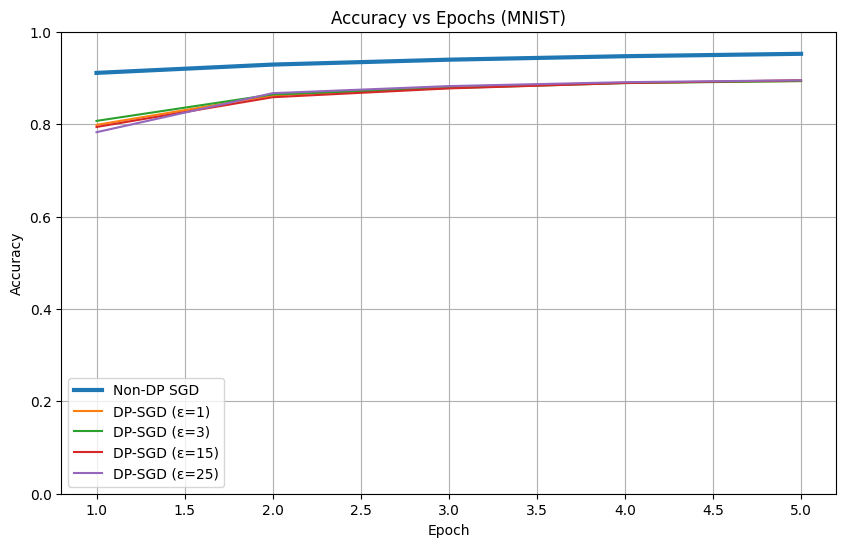

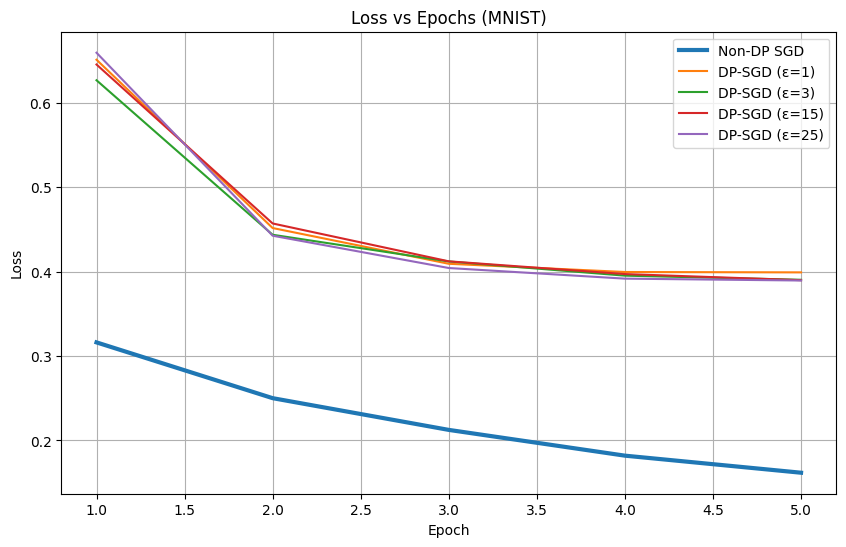

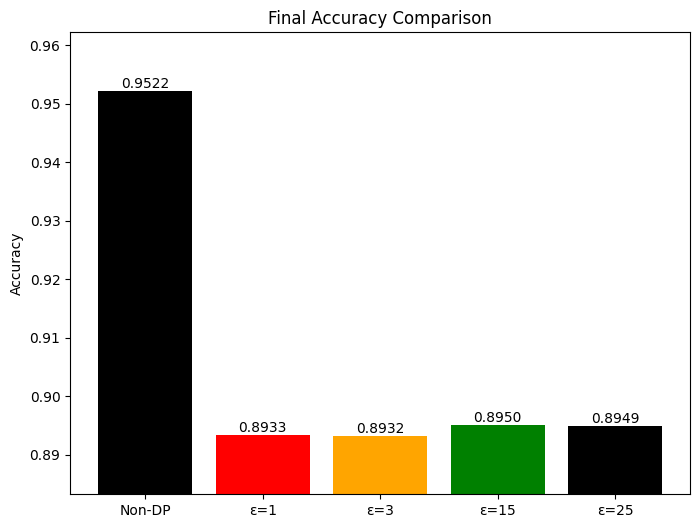

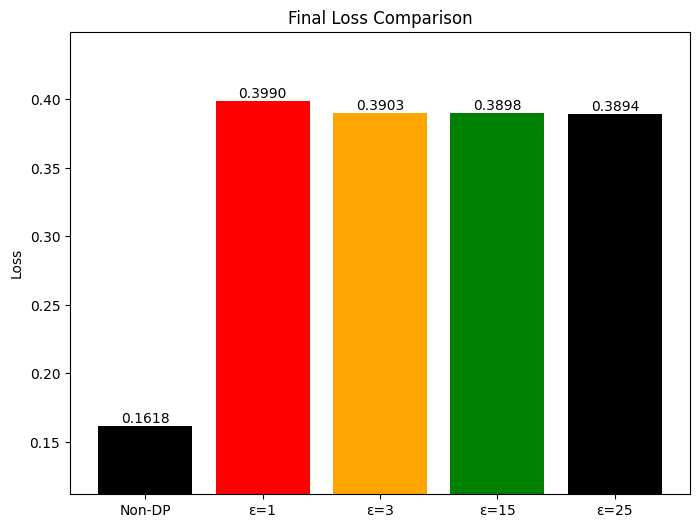

In [4]:
epochs = np.arange(1, EPOCHS + 1)

# -----------------------------
# Plot 1: Accuracy Comparison
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, results["non_dp"]["acc"], label="Non-DP SGD", linewidth=3)

for eps in EPSILONS:
    plt.plot(epochs, results["dp"][eps]["acc"], label=f"DP-SGD (ε={eps})")

plt.title("Accuracy vs Epochs (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Plot 2: Loss Comparison
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, results["non_dp"]["loss"], label="Non-DP SGD", linewidth=3)

for eps in EPSILONS:
    plt.plot(epochs, results["dp"][eps]["loss"], label=f"DP-SGD (ε={eps})")

plt.title("Loss vs Epochs (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Plot 3: Final Accuracy Bar Chart
# -----------------------------
plt.figure(figsize=(8,6))

labels = ["Non-DP"] + [f"ε={e}" for e in EPSILONS]
values = [results["non_dp"]["acc"][-1]] + [results["dp"][e]["acc"][-1] for e in EPSILONS]

bars = plt.bar(labels, values, color=["black", "red", "orange", "green"])

plt.title("Final Accuracy Comparison")
plt.ylabel("Accuracy")

min_val = min(values)
max_val = max(values)
margin = 0.01
plt.ylim(min_val - margin, max_val + margin)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center', va='bottom')

plt.show()


# -----------------------------
# Plot 4: Final Loss Bar Chart
# -----------------------------
plt.figure(figsize=(8,6))

labels = ["Non-DP"] + [f"ε={e}" for e in EPSILONS]
values = [results["non_dp"]["loss"][-1]] + [results["dp"][e]["loss"][-1] for e in EPSILONS]

bars = plt.bar(labels, values, color=["black", "red", "orange", "green"])

plt.title("Final Loss Comparison")
plt.ylabel("Loss")

min_val = min(values)
max_val = max(values)
margin = 0.05
plt.ylim(min_val - margin, max_val + margin)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center', va='bottom')

plt.show()